# 01 — What does a decoder see?

The surface-code decoder never sees the qubits, or the errors, or a code. It sees a list of bits: which stabilizer measurements disagreed with the round before. This notebook builds that object and asks what a standard decoder actually sees.

The answer is the reason the rest of this project exists:

> The standard *graphlike* error model splits the detection events into two halves that share no edges at all. The half a logical-$Z$ memory experiment supposedly does not need turns out to predict, well above chance, when matching gets the answer wrong.

In [1]:
!pip install -q stim pymatching
!curl -sSfLO https://raw.githubusercontent.com/LukeJamesMiller/hardware-aware-surface-code-decoding/refs/heads/main/qec_utils.py

%matplotlib inline
import os

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pymatching
import stim
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve

from qec_utils import RotatedSurfaceCode, blue, gf2_rank, gray, orange, plot_code
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

# One physical error rate is used for every illustration below.
P = 0.005
print(f"stim {stim.__version__} | pymatching {pymatching.__version__}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 47.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.2/626.2 kB 30.6 MB/s eta 0:00:00
stim 1.16.0 | pymatching 2.4.0


## 1. The code

`RotatedSurfaceCode` is built from the stabilizer rule alone in
[`qec_utils.py`](qec_utils.py), next to this notebook. 

$d^2$ data qubits, $d^2 - 1$ independent stabilizers split evenly between $X$ and $Z$
type. $H_X$ and $H_Z$ have one row per check and one
column per data qubit.

In [7]:
codes = {d: RotatedSurfaceCode(d) for d in (3, 5)}

for d, code in codes.items():
    lx = code.vector(code.logical_x)
    lz = code.vector(code.logical_z)
    print(f"d = {d}:  {code.n_data} data, {len(code.x_checks)}X + "
          f"{len(code.z_checks)}Z checks, k = {code.n_logical}, "
          f"logical weight {len(code.logical_x)}  OK")

d = 3:  9 data, 4X + 4Z checks, k = 1, logical weight 3  OK
d = 5:  25 data, 12X + 12Z checks, k = 1, logical weight 5  OK


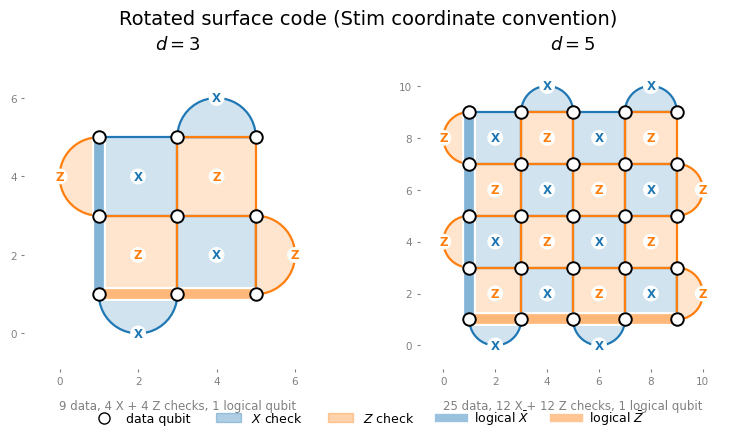

In [8]:
plot_code(list(codes.values()), "figures/code_geometry.png")
plt.show()

## 2. The memory circuit

A memory experiment does nothing except try to keep a logical state alive. 

In [9]:
def memory_circuit(d, p=P, rounds=None):
    # Uniform circuit-level noise. p = 0 gives the ideal circuit.
    return stim.Circuit.generated(
        "surface_code:rotated_memory_z", distance=d, rounds=d,
        after_clifford_depolarization=p, before_measure_flip_probability=p,
        after_reset_flip_probability=p, before_round_data_depolarization=p,
    )

summary = []
for d in (3, 5):
    ideal = memory_circuit(d)
    summary.append({
        "d": d, "rounds": d,
        "qubits": ideal.num_qubits,
        "measurements": ideal.num_measurements,
        "detectors": ideal.num_detectors,
        "observables": ideal.num_observables,
    })
pd.DataFrame(summary).set_index("d")

,rounds,qubits,measurements,detectors,observables
d,,,,,
3,3,26,33,24,1
5,5,64,145,120,1


## 3. Detection events

A **detector** is a parity of measurement outcomes that is deterministic when
nothing goes wrong. It fires when that parity comes out wrong. S

With no noise, nothing fires at all.

In [10]:
d=3
det, obs = stim.Circuit.generated(
        "surface_code:rotated_memory_z", distance=d, rounds=d,
        after_clifford_depolarization=p, before_measure_flip_probability=p,
        after_reset_flip_probability=p, before_round_data_depolarization=p,
    ).compile_detector_sampler().sample(1000, separate_observables=True)
print(f"noiseless: {det.sum()} detection events and {obs.sum()} observable flips "
      f"across {det.shape[0]} shots x {det.shape[1]} detectors  OK")

noiseless: 1367 detection events and 91 observable flips across 1000 shots x 24 detectors  OK


In [11]:
ideal_flat = memory_circuit(3).flattened()
lines = str(ideal_flat).splitlines()
coords3 = ideal_flat.get_detector_coordinates()

def sector(i, coords=coords3):
    # X ancillas sit where (x + y) / 2 is odd; Z ancillas where it is even.
    x, y, _ = coords[i]
    return "X" if ((int(x) + int(y)) // 2) % 2 == 1 else "Z"

def label(i, coords=coords3):
    x, y, t = (int(v) for v in coords[i])
    return f"({x},{y})@t{t}[{sector(i, coords)}]"

def inject(instruction, after_line):
    modified = list(lines)
    modified.insert(after_line, instruction)
    d, o = stim.Circuit("\n".join(modified)).compile_detector_sampler().sample(
        1, separate_observables=True)
    return np.flatnonzero(d[0]), int(o[0, 0])

# Inject after round 1's ancilla measurement, where both Pauli components are live.
after_round_1 = next(i for i, l in enumerate(lines) if l.strip().startswith("MR ")) + 1

faults = [
    ("X on data (1,1)",          "X_ERROR(1) 1",  after_round_1),
    ("Z on data (1,1)",          "Z_ERROR(1) 1",  after_round_1),
    ("Y on data (1,1)",          "Y_ERROR(1) 1",  after_round_1),
    ("X on data (3,3), bulk",    "X_ERROR(1) 10", after_round_1),
    ("Y on data (3,3), bulk",    "Y_ERROR(1) 10", after_round_1),
    ("misread of ancilla (2,2)", "X_ERROR(1) 9",  after_round_1 - 1),
]
rows = []
for name, instruction, where in faults:
    fired, flip = inject(instruction, where)
    rows.append({
        "fault": name,
        "detectors fired": " ".join(label(i) for i in fired) or "none",
        "sectors": "+".join(sorted({sector(i) for i in fired})) or "-",
        "flips observable": flip,
    })
pd.DataFrame(rows).set_index("fault")

,detectors fired,sectors,flips observable
fault,,,
"X on data (1,1)","(2,2)@t1[Z]",Z,1
"Z on data (1,1)","(2,0)@t1[X]",X,0
"Y on data (1,1)","(2,0)@t1[X] (2,2)@t1[Z]",X+Z,1
"X on data (3,3), bulk","(2,2)@t1[Z] (4,4)@t1[Z] (2,4)@t2[X] (4,4)@t2[Z...",X+Z,0
"Y on data (3,3), bulk","(4,4)@t0[Z] (6,2)@t0[Z] (2,2)@t1[Z] (4,2)@t1[X...",X+Z,0
"misread of ancilla (2,2)","(2,2)@t0[Z] (2,2)@t1[Z]",Z,0


Read the last column against the third.


In [12]:
def mechanisms(dem):
    out = []
    for instruction in dem.flattened():
        if instruction.type != "error":
            continue
        components, current, flip = [], [], 0
        for target in instruction.targets_copy():
            if target.is_separator():
                components.append(current); current = []
            elif target.is_relative_detector_id():
                current.append(target.val)
            elif target.is_logical_observable_id():
                flip ^= 1
        components.append(current)
        out.append((instruction.args_copy()[0], components, flip))
    return out

noisy3 = memory_circuit(3, P)
dem_graphlike = noisy3.detector_error_model(decompose_errors=True)
dem_true = noisy3.detector_error_model(decompose_errors=False)

graph = nx.Graph()
graph.add_nodes_from(range(dem_graphlike.num_detectors))
for _, comps, _ in mechanisms(dem_graphlike):
    for comp in comps:
        if len(comp) == 2:
            graph.add_edge(*comp)

parts = sorted(nx.connected_components(graph), key=len, reverse=True)
print(f"graphlike detector graph: {graph.number_of_nodes()} detectors, "
      f"{graph.number_of_edges()} edges")
print(f"connected components: {len(parts)}")
for part in parts:
    print(f"   {len(part):2d} detectors, sector(s) {sorted({sector(i) for i in part})}")


graphlike detector graph: 24 detectors, 54 edges
connected components: 2
   16 detectors, sector(s) ['Z']
    8 detectors, sector(s) ['X']


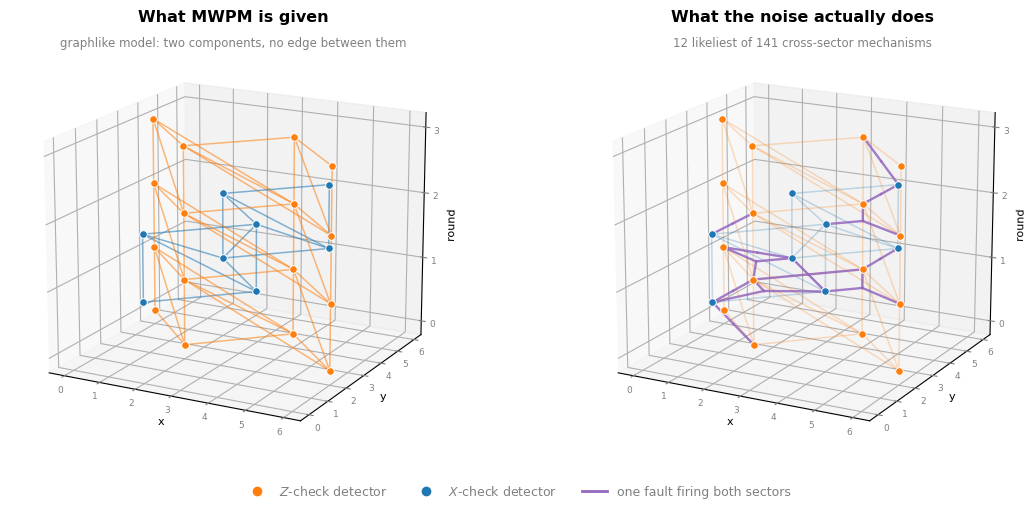

In [13]:
purple = "tab:purple"
colour = {"X": blue, "Z": orange}
position = {i: tuple(int(v) for v in dem_graphlike.get_detector_coordinates()[i])
            for i in range(dem_graphlike.num_detectors)}

edges = {(min(a, b), max(a, b)) for _, comps, _ in mechanisms(dem_graphlike)
         for comp in comps if len(comp) == 2 for a, b in [comp]}
cross_sector = [(p, c[0]) for p, c, _ in mechanisms(dem_true)
                if len({sector(i) for i in c[0]}) > 1]
featured = sorted(cross_sector, key=lambda t: -t[0])[:12]

figure = plt.figure(figsize=(11.5, 4.8))
for panel, show_cross in enumerate((False, True)):
    ax = figure.add_subplot(1, 2, panel + 1, projection="3d")
    for a, b in edges:
        xs, ys, ts = zip(*(position[a], position[b]))
        ax.plot(xs, ys, ts, color=colour[sector(a)], lw=1.1,
                alpha=0.25 if show_cross else 0.55)
    if show_cross:
        for _, dets in featured:
            centre = np.mean([position[i] for i in dets], axis=0)
            for i in dets:
                ax.plot([centre[0], position[i][0]], [centre[1], position[i][1]],
                        [centre[2], position[i][2]], color=purple, lw=1.7, alpha=0.85)
    for which in ("Z", "X"):
        pts = np.array([position[i] for i in position if sector(i) == which])
        ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], s=30, c=colour[which],
                   edgecolors="white", linewidths=0.7, depthshade=False)
    ax.set_xlabel("x", fontsize=8, labelpad=-8)
    ax.set_ylabel("y", fontsize=8, labelpad=-8)
    ax.set_zlabel("round", fontsize=8, labelpad=-8)
    ax.set_zticks(range(4))
    ax.tick_params(labelsize=6.5, pad=-3, colors=gray)
    ax.set_box_aspect((1, 1, 0.85))
    ax.view_init(elev=17, azim=-62)
    title, subtitle = [
        ("What MWPM is given", "graphlike model: two components, no edge between them"),
        ("What the noise actually does",
         f"12 likeliest of {len(cross_sector)} cross-sector mechanisms"),
    ][panel]
    ax.set_title(title, fontsize=11.5, pad=-4, weight="bold")
    ax.text2D(0.5, 0.95, subtitle, transform=ax.transAxes, ha="center",
              fontsize=8.5, color=gray)

handles = [
    plt.Line2D([], [], marker="o", ls="none", color=colour["Z"], label="$Z$-check detector"),
    plt.Line2D([], [], marker="o", ls="none", color=colour["X"], label="$X$-check detector"),
    plt.Line2D([], [], color=purple, lw=2, label="one fault firing both sectors"),
]
figure.legend(handles=handles, loc="lower center", ncol=3, frameon=False, fontsize=9,
              bbox_to_anchor=(0.5, -0.02), labelcolor=gray)
figure.subplots_adjust(left=0.01, right=0.99, top=0.99, bottom=0.06, wspace=0.02)
figure.savefig("figures/detector_graph.png", dpi=150, bbox_inches="tight")
plt.show()

In [14]:
facts = []
for d in (3, 5):
    circuit = memory_circuit(d, P)
    true = mechanisms(circuit.detector_error_model(decompose_errors=False))
    graphlike = mechanisms(circuit.detector_error_model(decompose_errors=True))

    sizes = pd.Series([len(c[0]) for _, c, _ in true]).value_counts().sort_index()
    total_mass = sum(p for p, _, _ in true)
    coords_d = circuit.detector_error_model().get_detector_coordinates()
    cross = [(p, c[0]) for p, c, _ in true
             if len({sector(i, coords_d) for i in c[0]}) > 1]
    facts.append({
        "d": d,
        "fault mechanisms": len(true),
        "after decomposition": len(graphlike),
        "hyperedges (>2 detectors)": sum(1 for _, c, _ in true if len(c[0]) > 2),
        "cross-sector mechanisms": len(cross),
        "cross-sector share of error probability":
            f"{sum(p for p, _ in cross) / total_mass:.1%}",
    })
    if d == 3:
        print("detectors per fault mechanism, before decomposition:")
        for size, count in sizes.items():
            print(f"   {size} detector(s): {count:4d} mechanisms")
        print()

pd.DataFrame(facts).set_index("d")

detectors per fault mechanism, before decomposition:
   1 detector(s):   24 mechanisms
   2 detector(s):   82 mechanisms
   3 detector(s):   76 mechanisms
   4 detector(s):   37 mechanisms



,fault mechanisms,after decomposition,hyperedges (>2 detectors),cross-sector mechanisms,cross-sector share of error probability
d,,,,,
3,219,286,113,141,19.1%
5,1677,1953,1101,1175,23.9%


In [15]:
N_SHOTS = 200_000
blinding, samples = [], {}

for d in (3, 5):
    circuit = memory_circuit(d, P)
    dem = circuit.detector_error_model(decompose_errors=True)
    coords_d = dem.get_detector_coordinates()
    is_x = np.array([sector(i, coords_d) == "X" for i in range(dem.num_detectors)])

    detections, observable = circuit.compile_detector_sampler(seed=2026).sample(
        N_SHOTS, separate_observables=True)
    matcher = pymatching.Matching.from_detector_error_model(dem)
    predicted = matcher.decode_batch(detections)[:, 0]

    blinded = detections.copy()
    blinded[:, is_x] = False
    predicted_blind = matcher.decode_batch(blinded)[:, 0]

    changed = int((predicted != predicted_blind).sum())
    samples[d] = (detections, observable[:, 0], predicted, is_x)
    blinding.append({
        "d": d,
        "shots": N_SHOTS,
        "shots where an X detector fired": f"{detections[:, is_x].any(axis=1).mean():.1%}",
        "MWPM logical failure": f"{(predicted != observable[:, 0]).mean():.2e}",
        "no correction": f"{observable[:, 0].mean():.2e}",
        "predictions changed by erasing X sector": changed,
    })

pd.DataFrame(blinding).set_index("d")

,shots,shots where an X detector fired,MWPM logical failure,no correction,predictions changed by erasing X sector
d,,,,,
3,200000,36.8%,1.72e-02,1.05e-01,0
5,200000,92.4%,1.43e-02,2.30e-01,0


In [16]:
auc, curves = [], {}
rng = np.random.default_rng(0)

for d, (detections, truth, predicted, is_x) in samples.items():
    residual = (predicted ^ truth).astype(int)     # 1 exactly where MWPM was wrong
    half = len(residual) // 2
    row = {"d": d, "MWPM failures in test half": int(residual[half:].sum())}
    for name, columns, shuffle in [
        ("X-sector bits", is_x, False),
        ("Z-sector bits", ~is_x, False),
        ("X-sector, shuffled (control)", is_x, True),
    ]:
        features = detections[:, columns].astype(np.float32)
        if shuffle:
            features = features.copy()
            rng.shuffle(features)
        model = LogisticRegression(max_iter=2000, class_weight="balanced")
        model.fit(features[:half], residual[:half])
        score = model.decision_function(features[half:])
        row[name] = roc_auc_score(residual[half:], score)
        if d == 5:
            curves[name] = roc_curve(residual[half:], score)
    auc.append(row)

table = pd.DataFrame(auc).set_index("d")
table

,MWPM failures in test half,X-sector bits,Z-sector bits,"X-sector, shuffled (control)"
d,,,,
3,1742,0.699461,0.874814,0.502206
5,1433,0.697893,0.787528,0.510557


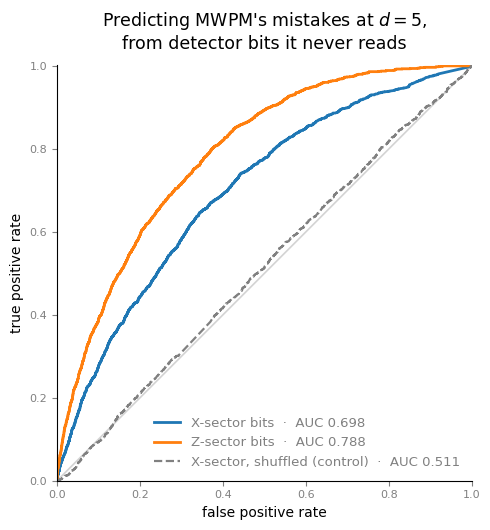

In [17]:
figure, ax = plt.subplots(figsize=(5.8, 5.4))
styling = {
    "Z-sector bits": (orange, "-", 2.0),
    "X-sector bits": (blue, "-", 2.0),
    "X-sector, shuffled (control)": (gray, "--", 1.6),
}
ax.plot([0, 1], [0, 1], color="lightgray", lw=1.2, zorder=0)
for name, (fpr, tpr, _) in curves.items():
    line_colour, style, width = styling[name]
    # ROC curves all converge at (0,0) and (1,1), so a floating direct label
    # collides with a neighbour at any offset. The value sits beside its swatch.
    ax.plot(fpr, tpr, color=line_colour, ls=style, lw=width, zorder=2,
            label=f"{name}  ·  AUC {table.loc[5, name]:.3f}")
ax.set_xlabel("false positive rate", fontsize=10)
ax.set_ylabel("true positive rate", fontsize=10)
ax.set_title("Predicting MWPM's mistakes at $d = 5$,\nfrom detector bits it never reads",
             fontsize=12.5, pad=12)
ax.set_xlim(0, 1); ax.set_ylim(0, 1.001); ax.set_aspect("equal")
ax.tick_params(labelsize=8, colors=gray)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
ax.legend(loc="lower right", frameon=False, fontsize=9.5, labelcolor=gray)
figure.tight_layout()
figure.savefig("figures/discarded_information.png", dpi=200, bbox_inches="tight")
plt.show()

In [18]:
record = (pd.DataFrame(facts).set_index("d")
          .join(pd.DataFrame(blinding).set_index("d"))
          .join(table))
record.insert(0, "physical_error_rate", P)
record.to_csv("results/detector_model_facts.csv")
print("written: results/detector_model_facts.csv")
record.T

written: results/detector_model_facts.csv


d,3,5
physical_error_rate,0.005,0.005
fault mechanisms,219,1677
after decomposition,286,1953
hyperedges (>2 detectors),113,1101
cross-sector mechanisms,141,1175
cross-sector share of error probability,19.1%,23.9%
shots,200000,200000
shots where an X detector fired,36.8%,92.4%
MWPM logical failure,1.72e-02,1.43e-02
no correction,1.05e-01,2.30e-01
